# 07 — Weather Dataset Visualisation

Explores the **NOAA ISD** weather data bundled with C2G-Bench and the
calibrated **synthetic two-harmonic climate models** for all six market presets.

| Section | Content |
|---------|---------|
| 1 | Real NOAA data — NYC & LONGIL annual profiles |
| 2 | Diurnal patterns by season |
| 3 | Synthetic model vs. real data comparison |
| 4 | All-market synthetic temperature envelopes |
| 5 | COP degradation as a function of ambient temperature |
| 6 | Observation normalisation per market |
| 7 | Southern-hemisphere phase flip (AEMO NSW) |

## 1 — Import libraries

In [1]:
import sys, warnings
from pathlib import Path

ROOT = Path(".").resolve().parent   # repo root when notebook is in notebooks/
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns

# C2G-Bench weather module
from c2g_env.physics.weather import WeatherLoader, WEATHER_PRESETS

sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.05)
FIGDIR = Path(".")          # save figures alongside notebook
DATA   = ROOT / "data" / "processed" / "weather"
print("Root:", ROOT)
print("Presets:", list(WEATHER_PRESETS.keys()))

Root: /lustre/guillant/C2G-Macro
Presets: ['nyiso_nyc', 'pjm_dom', 'caiso_pgae', 'ercot_north', 'entso_de', 'aemo_nsw']


## 2 — Load real NOAA ISD data

Two zones are bundled: **NYC** (Central Park, station 725053) and
**LONGIL** (JFK Int'l, station 744860).

In [2]:
def load_zone(name):
    df = pd.read_csv(DATA / f"{name}.csv", parse_dates=["timestamp_utc"])
    df = df.sort_values("timestamp_utc").reset_index(drop=True)
    df["month"]  = df["timestamp_utc"].dt.month
    df["hour"]   = df["timestamp_utc"].dt.hour
    df["day_of_year"] = df["timestamp_utc"].dt.day_of_year
    def _season(m):
        if m in [12, 1, 2]: return "Winter"
        if m in [3, 4, 5]:  return "Spring"
        if m in [6, 7, 8]:  return "Summer"
        return "Autumn"
    df["season"] = df["month"].map(_season)
    return df

nyc    = load_zone("NYC")
longil = load_zone("LONGIL")

print(f"NYC rows:    {len(nyc):,} | date range: {nyc.timestamp_utc.min().date()} → {nyc.timestamp_utc.max().date()}")
print(f"LONGIL rows: {len(longil):,} | date range: {longil.timestamp_utc.min().date()} → {longil.timestamp_utc.max().date()}")
nyc.head(3)

NYC rows:    8,739 | date range: 2024-01-01 → 2024-12-31
LONGIL rows: 8,764 | date range: 2024-01-01 → 2024-12-31


,timestamp_utc,zone,station_id,station_name,temp_c,dewpoint_c,month,hour,day_of_year,season
0,2024-01-01 01:00:00+00:00,NYC,725053-94728,Central Park,6.1,-4.4,1,1,1,Winter
1,2024-01-01 02:00:00+00:00,NYC,725053-94728,Central Park,5.6,-3.3,1,2,1,Winter
2,2024-01-01 03:00:00+00:00,NYC,725053-94728,Central Park,6.1,-2.8,1,3,1,Winter


## 3 — Annual temperature profile — all 6 markets

Real NOAA CSV data is used where available (NYC, LONGIL).
For the remaining four markets the calibrated synthetic two-harmonic
model is used automatically by `WeatherLoader`.

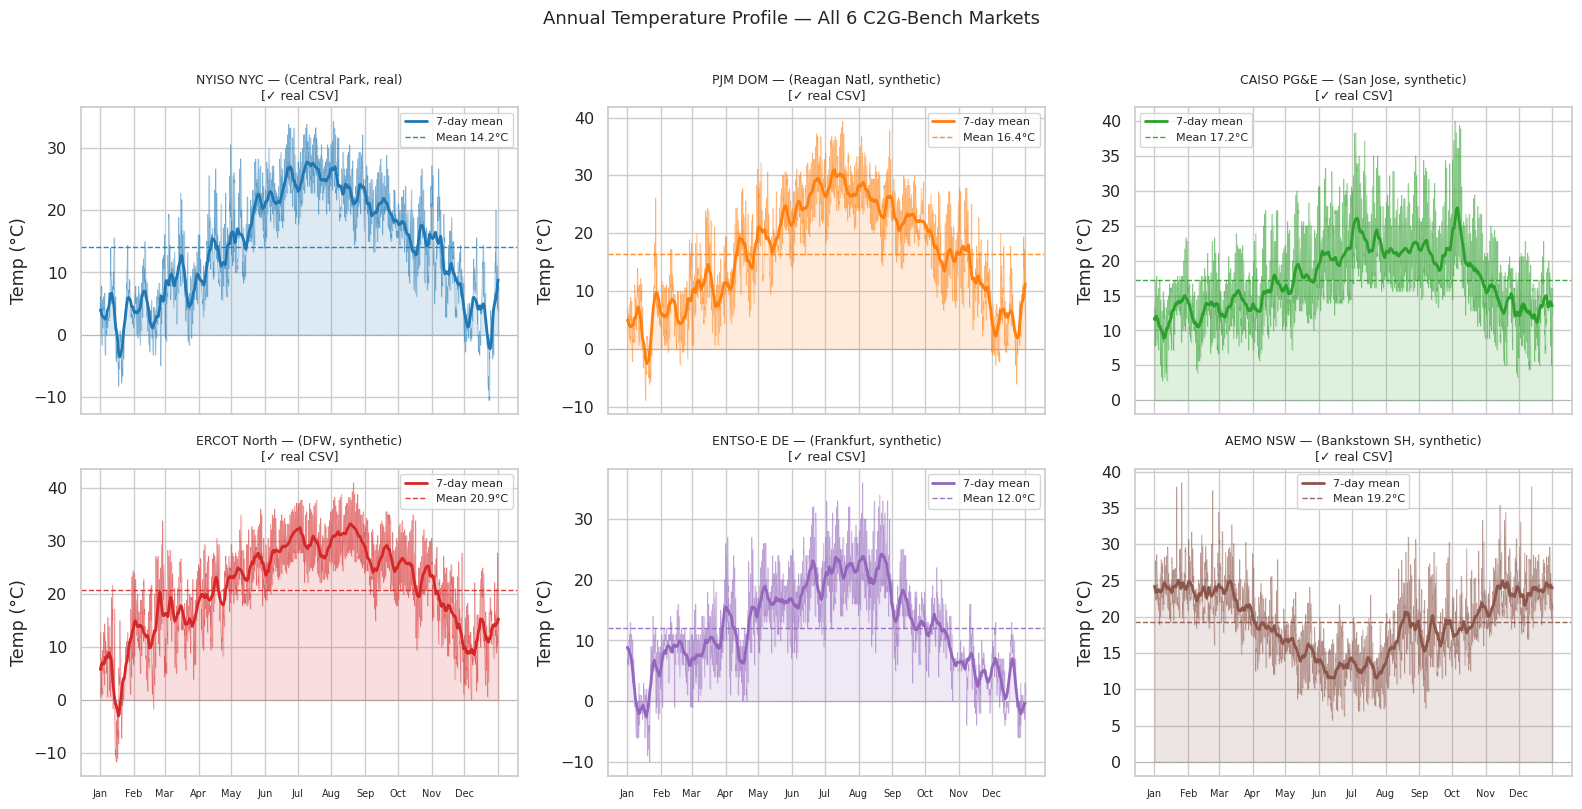


Data sources:
  nyiso_nyc         real:NYC.csv
  pjm_dom           real:DCA.csv
  caiso_pgae        real:SJC.csv
  ercot_north       real:DFW.csv
  entso_de          real:FRA.csv
  aemo_nsw          real:BKT.csv


In [3]:
MARKET_LABELS = {
    "nyiso_nyc":   "NYISO NYC\n(Central Park, real)",
    "pjm_dom":     "PJM DOM\n(Reagan Natl, synthetic)",
    "caiso_pgae":  "CAISO PG&E\n(San Jose, synthetic)",
    "ercot_north": "ERCOT North\n(DFW, synthetic)",
    "entso_de":    "ENTSO-E DE\n(Frankfurt, synthetic)",
    "aemo_nsw":    "AEMO NSW\n(Bankstown SH, synthetic)",
}
COLORS = plt.rcParams["axes.prop_cycle"].by_key()["color"]

# Build one year of hourly temperatures per market via WeatherLoader
# (uses real CSV if present, otherwise calibrated synthetic)
hours_yr = 365 * 24
records = []
for mkt, color in zip(MARKET_LABELS, COLORS):
    p    = WEATHER_PRESETS[mkt]
    wdir = DATA if (p.zone_file and (DATA / f"{p.zone_file}.csv").exists()) else Path("/tmp/__nx__")
    wl   = WeatherLoader(weather_dir=wdir, market=mkt, dt_seconds=3600)
    temps = np.array([wl.temp_c(t) for t in range(hours_yr)])
    day   = np.arange(hours_yr) / 24.0
    for d, t in zip(day, temps):
        records.append({"market": mkt, "day": d, "temp_c": t,
                        "source": wl.source.split(":")[0]})

df_all = pd.DataFrame(records)

# ── 2×3 subplots, one per market ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 8), sharex=True)
month_tick_days = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334, 365]
month_names     = ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec",""]

for ax, (mkt, color) in zip(axes.flat, zip(MARKET_LABELS, COLORS)):
    sub = df_all[df_all["market"] == mkt]
    temps_arr = sub["temp_c"].values
    days_arr  = sub["day"].values

    # 7-day rolling mean
    rol = pd.Series(temps_arr).rolling(168, center=True, min_periods=1).mean().values

    ax.fill_between(days_arr, temps_arr, alpha=0.15, color=color)
    ax.plot(days_arr, temps_arr, lw=0.3, color=color, alpha=0.6)
    ax.plot(days_arr, rol,       lw=2.0, color=color, label="7-day mean")

    p       = WEATHER_PRESETS[mkt]
    src_tag = sub["source"].iloc[0]
    ax.axhline(temps_arr.mean(), color=color, lw=1, ls="--", alpha=0.9,
               label=f"Mean {temps_arr.mean():.1f}°C")
    ax.axhline(0, color="grey", lw=0.5, ls=":")

    ax.set_xticks(month_tick_days)
    ax.set_xticklabels(month_names, fontsize=7)
    ax.set_ylabel("Temp (°C)")
    badge = "✓ real CSV" if src_tag == "real" else "◇ synthetic"
    ax.set_title(MARKET_LABELS[mkt].replace("\n", " — ") + f"\n[{badge}]", fontsize=9)
    ax.legend(fontsize=8)

fig.suptitle("Annual Temperature Profile — All 6 C2G-Bench Markets",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(FIGDIR / "fig_weather_annual.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nData sources:")
for mkt in MARKET_LABELS:
    p    = WEATHER_PRESETS[mkt]
    wdir = DATA if (p.zone_file and (DATA / f"{p.zone_file}.csv").exists()) else Path("/tmp/__nx__")
    wl   = WeatherLoader(weather_dir=wdir, market=mkt, dt_seconds=3600)
    print(f"  {mkt:<16}  {wl.source}")

## 4 — Diurnal patterns by season

Mean temperature for each hour of the day, split by meteorological season.

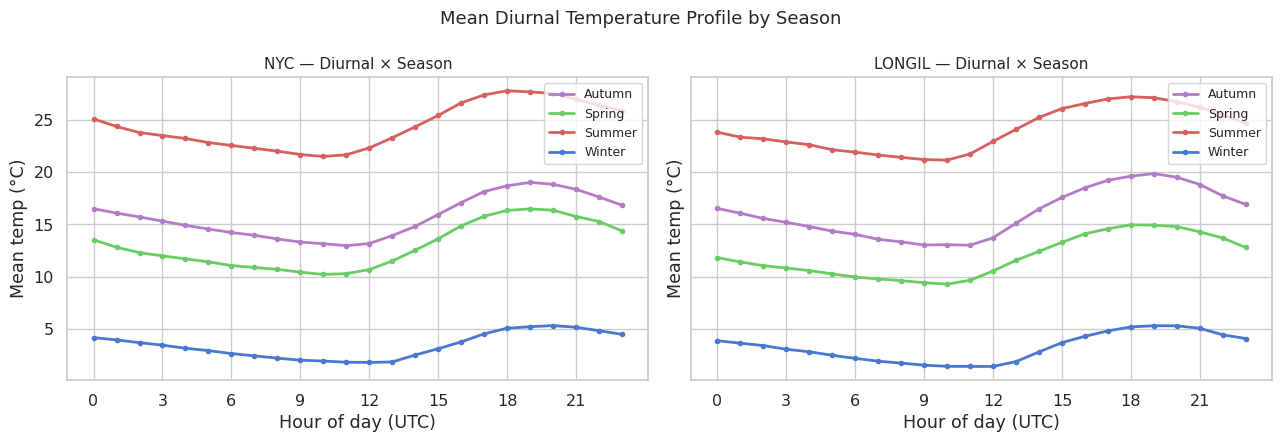

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
palette = {"Winter": "#4878cf", "Spring": "#6acc65",
           "Summer": "#d65f5f", "Autumn": "#b47cc7"}

for ax, (df, label) in zip(axes, [(nyc, "NYC"), (longil, "LONGIL")]):
    grouped = df.groupby(["season", "hour"])["temp_c"].mean().reset_index()
    for season, grp in grouped.groupby("season"):
        ax.plot(grp["hour"], grp["temp_c"], label=season,
                color=palette.get(season, None), lw=2, marker="o", ms=3)
    ax.set_xlabel("Hour of day (UTC)")
    ax.set_ylabel("Mean temp (°C)")
    ax.set_title(f"{label} — Diurnal × Season", fontsize=11)
    ax.set_xticks(range(0, 24, 3))
    ax.legend(fontsize=9)

fig.suptitle("Mean Diurnal Temperature Profile by Season", fontsize=13)
plt.tight_layout()
plt.savefig(FIGDIR / "fig_weather_diurnal.png", dpi=150, bbox_inches="tight")
plt.show()

## 5 — Synthetic model vs. real data (NYC)

The `WeatherLoader` falls back to a two-harmonic synthetic model when no CSV
is present. Here we compare the real NYC data with the synthetic
reconstruction to validate fidelity.

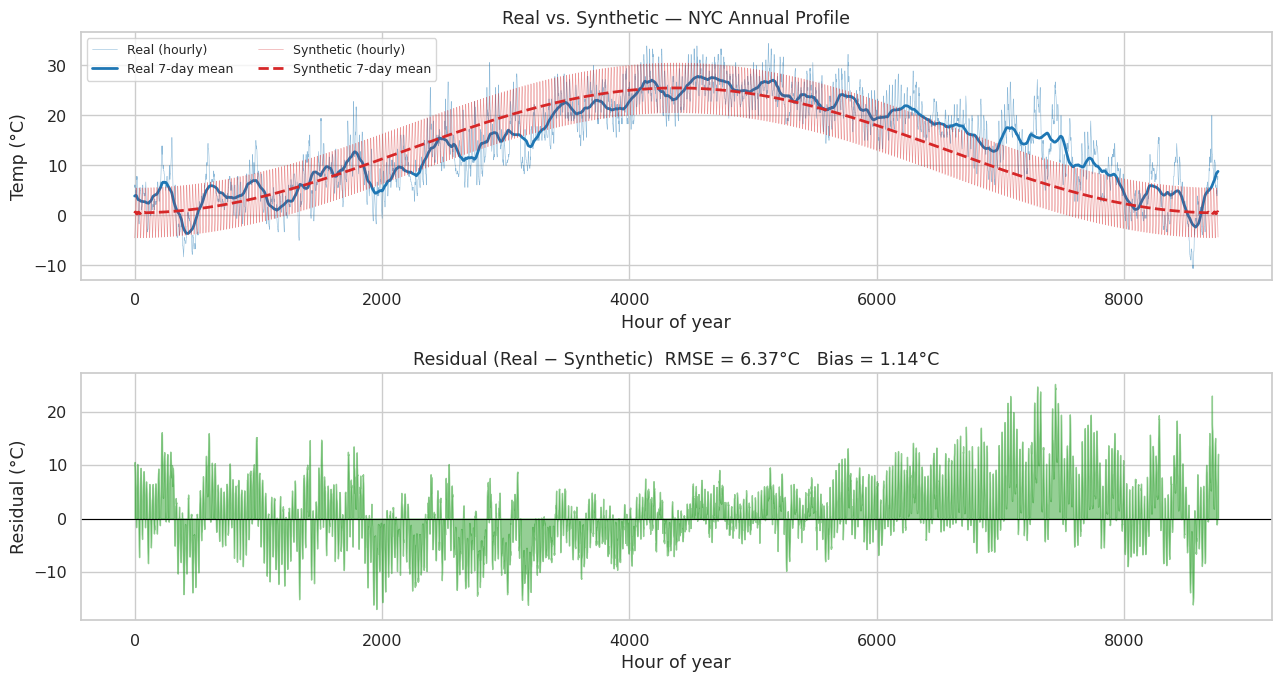

Source real:      real:NYC.csv
Source synthetic: synthetic:nyiso_nyc


In [5]:
# Build synthetic profile using the WeatherLoader's internal model
wl_real = WeatherLoader(weather_dir=DATA, market="nyiso_nyc", dt_seconds=3600)
wl_syn  = WeatherLoader(weather_dir=Path("/tmp/__nonexistent__"),
                         market="nyiso_nyc", dt_seconds=3600)

ticks_year = 365 * 24
real_temps = np.array([wl_real.temp_c(t) for t in range(ticks_year)])
syn_temps  = np.array([wl_syn.temp_c(t)  for t in range(ticks_year)])

# 7-day rolling mean for comparison
def rolling_mean(arr, n=168):
    return pd.Series(arr).rolling(n, center=True, min_periods=1).mean().values

x = np.arange(ticks_year)

fig, axes = plt.subplots(2, 1, figsize=(13, 7))

# Top: overlaid timeseries
ax = axes[0]
ax.plot(x, real_temps, lw=0.4, color="#1f77b4", alpha=0.5, label="Real (hourly)")
ax.plot(x, rolling_mean(real_temps), lw=2.0, color="#1f77b4", label="Real 7-day mean")
ax.plot(x, syn_temps, lw=0.4, color="#d62728", alpha=0.5, label="Synthetic (hourly)")
ax.plot(x, rolling_mean(syn_temps), lw=2.0, color="#d62728", ls="--", label="Synthetic 7-day mean")
ax.set_ylabel("Temp (°C)")
ax.set_xlabel("Hour of year")
ax.legend(ncol=2, fontsize=9)
ax.set_title("Real vs. Synthetic — NYC Annual Profile")

# Bottom: residual
ax2 = axes[1]
residual = real_temps - syn_temps
ax2.fill_between(x, residual, alpha=0.5, color="#2ca02c")
ax2.axhline(0, color="k", lw=0.8)
ax2.set_ylabel("Residual (°C)")
ax2.set_xlabel("Hour of year")
ax2.set_title(f"Residual (Real − Synthetic)  RMSE = {np.sqrt((residual**2).mean()):.2f}°C   "
              f"Bias = {residual.mean():.2f}°C")

plt.tight_layout()
plt.savefig(FIGDIR / "fig_weather_syn_vs_real.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Source real:      {wl_real.source}")
print(f"Source synthetic: {wl_syn.source}")

## 6 — All-market synthetic temperature envelopes

Seasonal envelope for all six market presets (monthly P10/P50/P90).

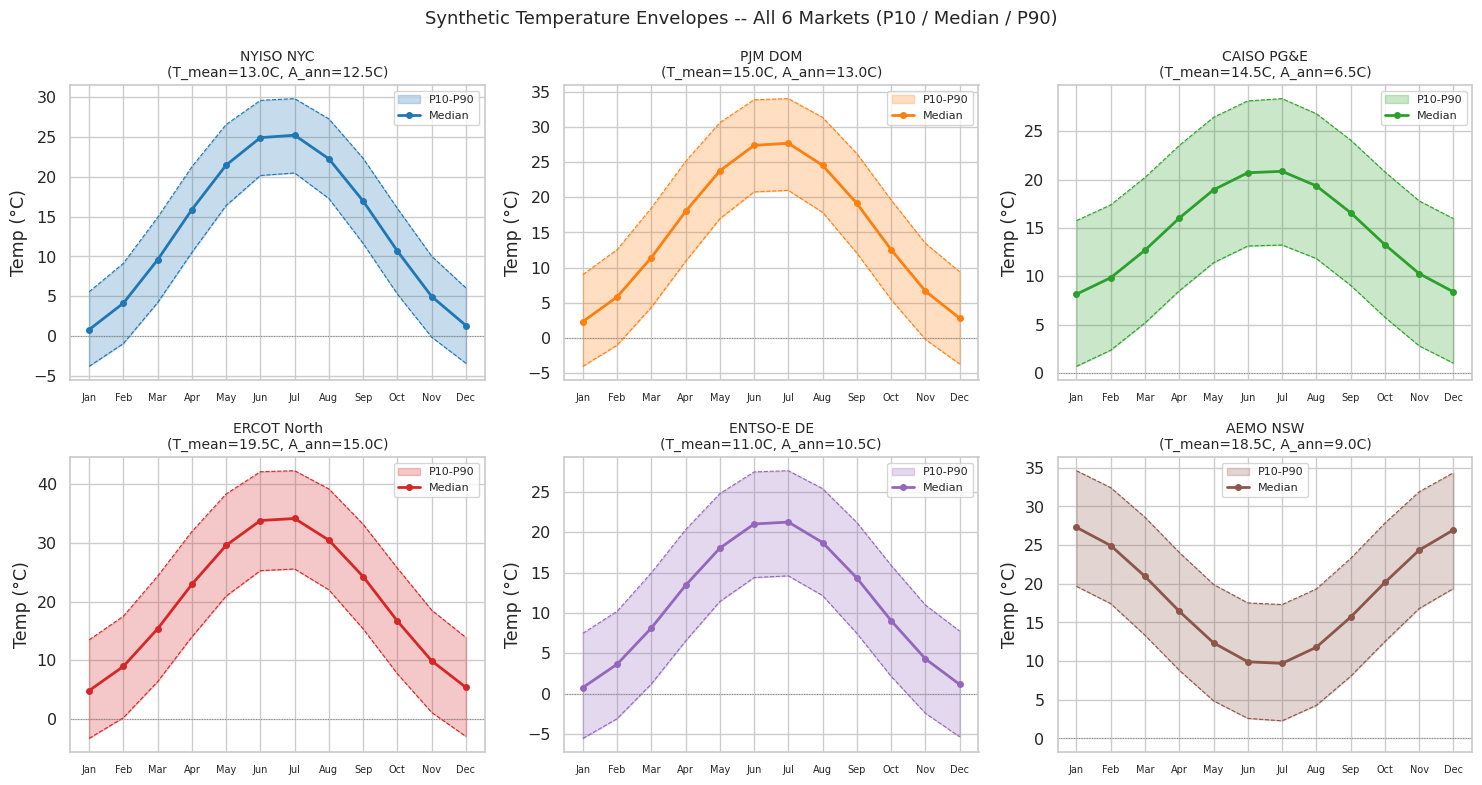

In [6]:
markets    = list(WEATHER_PRESETS.keys())
market_labels = {
    "nyiso_nyc":   "NYISO NYC",
    "pjm_dom":     "PJM DOM",
    "caiso_pgae":  "CAISO PG&E",
    "ercot_north": "ERCOT North",
    "entso_de":    "ENTSO-E DE",
    "aemo_nsw":    "AEMO NSW",
}
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
hoursperday = 24
daysperyr   = 365
hours_yr    = daysperyr * hoursperday

frames = {}
for mkt in markets:
    wl = WeatherLoader(weather_dir=Path("/tmp/__nx__"), market=mkt, dt_seconds=3600)
    temps = np.array([wl.temp_c(t) for t in range(hours_yr)])
    month = np.array([(h // hoursperday) // 30 % 12 + 1 for h in range(hours_yr)])
    frames[mkt] = pd.DataFrame({"temp_c": temps, "month": month})

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=False)
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for ax, (mkt, color) in zip(axes.flat, zip(markets, colors)):
    df = frames[mkt]
    p10 = df.groupby("month")["temp_c"].quantile(0.10).values
    p50 = df.groupby("month")["temp_c"].quantile(0.50).values
    p90 = df.groupby("month")["temp_c"].quantile(0.90).values
    x   = np.arange(1, 13)

    ax.fill_between(x, p10, p90, alpha=0.25, color=color, label="P10-P90")
    ax.plot(x, p50, color=color, lw=2, marker="o", ms=4, label="Median")
    ax.plot(x, p10, color=color, lw=0.8, ls="--")
    ax.plot(x, p90, color=color, lw=0.8, ls="--")
    ax.axhline(0, color="grey", lw=0.7, ls=":")
    ax.set_xticks(x)
    ax.set_xticklabels(month_labels, fontsize=7)
    ax.set_ylabel("Temp (°C)")
    ax.legend(fontsize=8)
    p    = WEATHER_PRESETS[mkt]
    ttl  = (market_labels[mkt]
            + "\n(T_mean=" + str(p.annual_mean_c) + "C, "
            + "A_ann=" + str(p.annual_amp_c) + "C)")
    ax.set_title(ttl, fontsize=10)

fig.suptitle("Synthetic Temperature Envelopes -- All 6 Markets (P10 / Median / P90)",
             fontsize=13)
plt.tight_layout()
plt.savefig(FIGDIR / "fig_weather_all_markets.png", dpi=150, bbox_inches="tight")
plt.show()

## 7 — Cooling COP degradation with ambient temperature

The Zone B CRAH COP in `ThermalTwin` is:

$$\text{COP}(T_{\text{amb}}) = 3.5 \cdot \max(0.3,\; 1 - 0.02 \cdot (T_{\text{amb}} - 25))$$

Higher ambient temperature means more fan energy for the same cooling output.

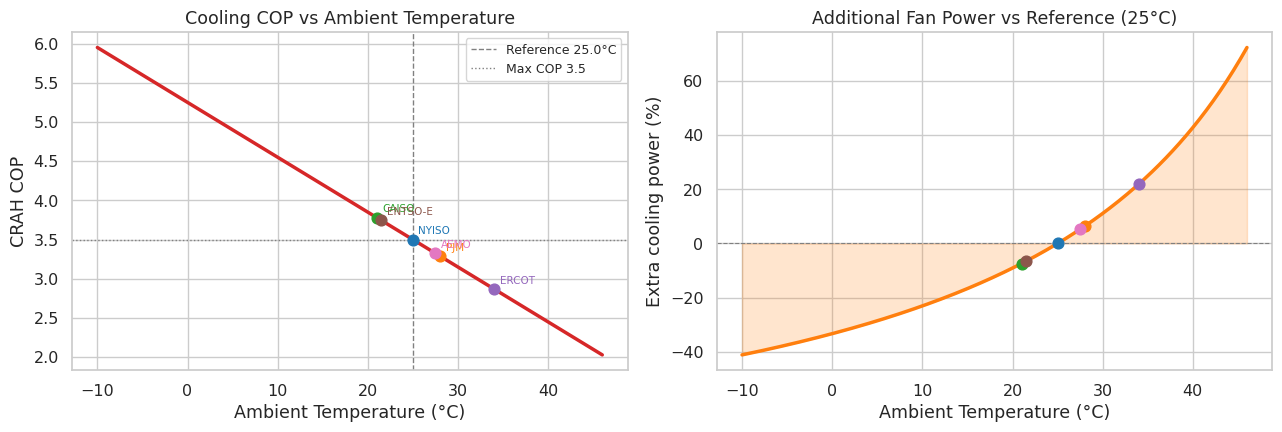

Extra power at 38°C vs 25°C: 35.1%


In [7]:
T_amb_range = np.linspace(-10, 46, 300)
COP_base = 3.5
COP_alpha = 0.02
T_ref = 25.0

cop = COP_base * np.maximum(0.3, 1 - COP_alpha * (T_amb_range - T_ref))
power_ratio = COP_base / cop   # power needed relative to reference

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# COP vs T_amb
ax1.plot(T_amb_range, cop, "#d62728", lw=2.5)
ax1.axvline(T_ref, color="grey", ls="--", lw=1, label=f"Reference {T_ref}°C")
ax1.axhline(COP_base, color="grey", ls=":", lw=1, label=f"Max COP {COP_base}")
# Mark each market's summer peak
summer_peaks = {
    "NYISO": (25.0, "#1f77b4"),
    "PJM": (28.0, "#ff7f0e"),
    "CAISO": (21.0, "#2ca02c"),
    "ERCOT": (34.0, "#9467bd"),
    "ENTSO-E": (21.5, "#8c564b"),
    "AEMO": (27.5, "#e377c2"),
}
for label, (t, c) in summer_peaks.items():
    cv = COP_base * max(0.3, 1 - COP_alpha * (t - T_ref))
    ax1.scatter(t, cv, color=c, zorder=5, s=60)
    ax1.annotate(label, (t, cv), textcoords="offset points",
                 xytext=(4, 4), fontsize=7.5, color=c)
ax1.set_xlabel("Ambient Temperature (°C)")
ax1.set_ylabel("CRAH COP")
ax1.set_title("Cooling COP vs Ambient Temperature")
ax1.legend(fontsize=9)

# Relative power overhead
ax2.plot(T_amb_range, (power_ratio - 1) * 100, "#ff7f0e", lw=2.5)
ax2.axhline(0, color="grey", lw=0.8, ls="--")
ax2.fill_between(T_amb_range, (power_ratio - 1) * 100, alpha=0.2, color="#ff7f0e")
ax2.set_xlabel("Ambient Temperature (°C)")
ax2.set_ylabel("Extra cooling power (%)")
ax2.set_title("Additional Fan Power vs Reference (25°C)")
for label, (t, c) in summer_peaks.items():
    pr = COP_base / (COP_base * max(0.3, 1 - COP_alpha * (t - T_ref)))
    ax2.scatter(t, (pr - 1) * 100, color=c, zorder=5, s=60)

plt.tight_layout()
plt.savefig(FIGDIR / "fig_weather_cop.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Extra power at 38°C vs 25°C: "
      f"{(COP_base / (COP_base * max(0.3, 1 - COP_alpha * (38 - T_ref))) - 1)*100:.1f}%")

## 8 — Observation normalisation per market

`temp_norm()` clips each market's temperatures to its `[norm_min_c, norm_max_c]` bounds.
This plot shows how the real NYC distribution uses the normalisation range.

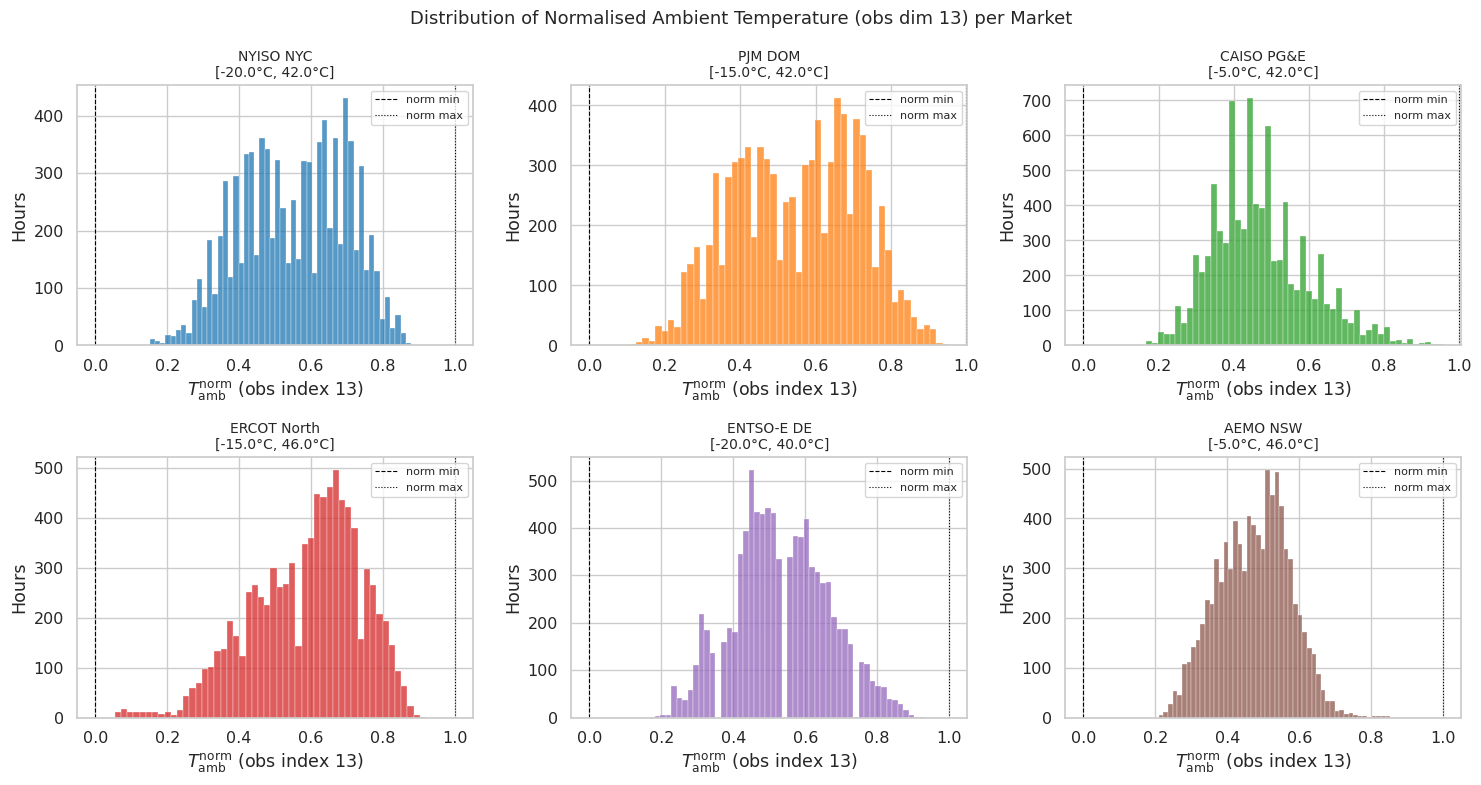

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
markets    = list(WEATHER_PRESETS.keys())
market_labels = {
    "nyiso_nyc":   "NYISO NYC",
    "pjm_dom":     "PJM DOM",
    "caiso_pgae":  "CAISO PG&E",
    "ercot_north": "ERCOT North",
    "entso_de":    "ENTSO-E DE",
    "aemo_nsw":    "AEMO NSW",
}
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
hoursperday = 24
daysperyr   = 365
hours_yr    = daysperyr * hoursperday

for ax, (mkt, color) in zip(axes.flat, zip(markets, colors)):
    p = WEATHER_PRESETS[mkt]
    zone_csv = DATA / f"{p.zone_file}.csv" if p.zone_file else None
    wdir = DATA if (zone_csv and zone_csv.exists()) else Path("/tmp/__nx__")
    wl = WeatherLoader(weather_dir=wdir, market=mkt, dt_seconds=3600)
    temps_norm = np.array([wl.temp_norm(t) for t in range(hours_yr)])

    ax.hist(temps_norm, bins=50, color=color, alpha=0.75, edgecolor="white", lw=0.3)
    ax.axvline(0, color="k", lw=0.8, ls="--", label="norm min")
    ax.axvline(1, color="k", lw=0.8, ls=":",  label="norm max")
    ax.set_xlabel(r"$T_{\mathrm{amb}}^{\mathrm{norm}}$ (obs index 13)")
    ax.set_ylabel("Hours")
    ax.set_title(f"{market_labels[mkt]}\n[{p.norm_min_c}°C, {p.norm_max_c}°C]", fontsize=10)
    ax.legend(fontsize=8)

fig.suptitle("Distribution of Normalised Ambient Temperature (obs dim 13) per Market",
             fontsize=13)
plt.tight_layout()
plt.savefig(FIGDIR / "fig_weather_normhist.png", dpi=150, bbox_inches="tight")
plt.show()

## 9 — Southern-hemisphere phase flip (AEMO NSW)

AEMO NSW is in the southern hemisphere — summer is in January and winter is in July.
The synthetic model negates the seasonal phase $\varphi$ to produce the correct envelope.

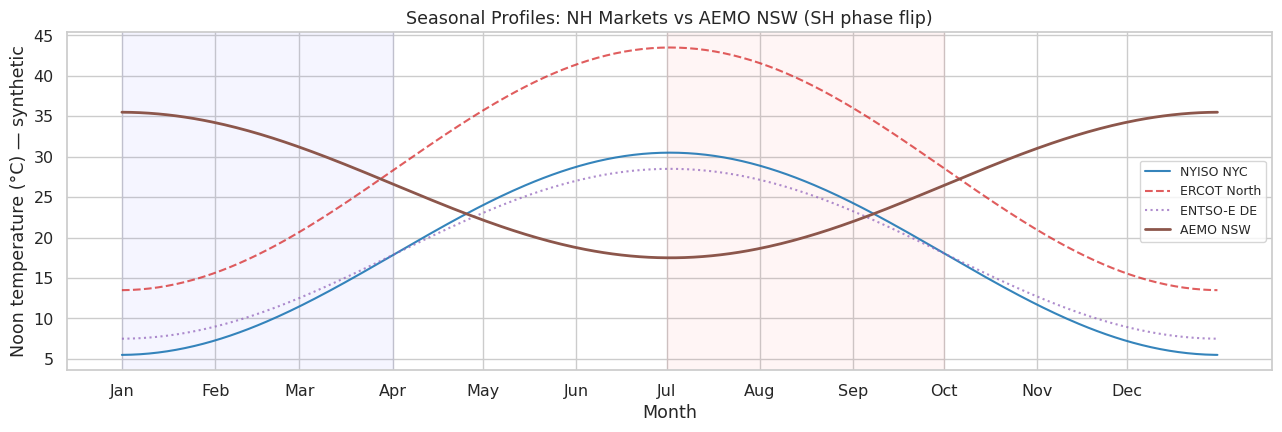

AEMO NSW summer peak month: Jan (day ~15) — 27.5°C max


In [9]:
fig, ax = plt.subplots(figsize=(13, 4.5))

nh_markets = ["nyiso_nyc", "ercot_north", "entso_de"]
sh_markets = ["aemo_nsw"]

days = np.arange(0, 365)
month_ticks = [0, 31, 59, 90, 120, 151, 181, 212, 243, 273, 304, 334]
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

for mkt, ls, alpha in [("nyiso_nyc", "-", 0.9), ("ercot_north", "--", 0.75),
                        ("entso_de", ":", 0.75), ("aemo_nsw", "-", 1.0)]:
    p  = WEATHER_PRESETS[mkt]
    c  = colors[markets.index(mkt)]
    # Noon temperature (h=12)
    wl = WeatherLoader(weather_dir=Path("/tmp/__nx__"), market=mkt, dt_seconds=3600)
    noon_temps = np.array([wl.temp_c(d * 24 + 12) for d in days])
    ax.plot(days, noon_temps, color=c, ls=ls, lw=2 if mkt == "aemo_nsw" else 1.5,
            alpha=alpha, label=market_labels[mkt])

ax.set_xticks(month_ticks)
ax.set_xticklabels(month_names)
ax.set_xlabel("Month")
ax.set_ylabel("Noon temperature (°C) — synthetic")
ax.set_title("Seasonal Profiles: NH Markets vs AEMO NSW (SH phase flip)")
ax.legend(fontsize=9)
ax.axvspan(0, 90, alpha=0.04, color="blue", label="NH Winter / SH Summer")
ax.axvspan(181, 273, alpha=0.04, color="red")

plt.tight_layout()
plt.savefig(FIGDIR / "fig_weather_sh_flip.png", dpi=150, bbox_inches="tight")
plt.show()
print("AEMO NSW summer peak month: Jan (day ~15) —",
      f"{WEATHER_PRESETS['aemo_nsw'].annual_mean_c + WEATHER_PRESETS['aemo_nsw'].annual_amp_c:.1f}°C max")